Essayer de capter des non-linéarités ou "effets de seuil": par ex, la variable population peut ne plus jouer en dessous d'un certain seuil de population. Aussi, le terme de richesse peut clairement ne pas être linéaire. C'est typiquement ce qu'un algorithme Random Forest peut capter. on va donc comparer les prédictions d'un Random Forest avec l'OLS

In [1]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np


# regression sur données présidentielles 2017 et 2022. 

# chemin relatif qui respecte l'arborescence du Git (pour rendre réplicable)
file_path_pres = os.path.join("..", "data", "merged", "data_regression_std_presidentielles.csv") # prendre les données standardisées!

# Chargement
df_reg_pres = pd.read_csv(file_path_pres)

OLS pour le SENS (valeurs pour les coeffs, signes).

RANDOM FOREST pour la HIERARCHIE (mesure à quel point chaque variable a permis de réduire l'erreur de variance)

Analyse des deux R^2 : un R^2 plus élevé pour le RANDOM FOREST signale des effets non linéaires de seuils indispensables à la prédiction correcte du vote. 

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

# Variables X et cible Y
features = ['score_gauche_pres_2017', 'log_pop_2022', 'log_med_19', 'pct_sup_2022']
X = df_reg_pres[features].dropna()
y = df_reg_pres.loc[X.index, 'score_gauche_pres_2022']

# Modèle Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X, y)

# Score
print(f"R² Random Forest: {r2_score(y, rf.predict(X)):.4f}")

# Importances
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nImportance des variables :")
print(importances)

# CROSS VALIDATION 
scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"R² moyen : {scores.mean():.4f} (+/- {scores.std():.4f})")

R² Random Forest: 0.8075

Importance des variables :
score_gauche_pres_2017    0.856400
pct_sup_2022              0.081408
log_pop_2022              0.042223
log_med_19                0.019969
dtype: float64
R² moyen : 0.7303 (+/- 0.0272)


Conclusion: 

std: pas un problème, le random forest est scale-invariant (très glouton) 
gestion de la profondeur et du nombre d'arbres: bon compromis biais-variance.

cela valide toute la démarche !! 
Un gain de 7 points sur le R^2 signifie que le RANDOM FOREST a réussi à capter des effets non linéaires (seuils, par exemple l'effet des diplômes n'est signifciatif qu'à partir d'un certain seuil de population). L'OLS échoue à cela, il écrase ces effets dans la moyenne. 

Attention: le RF est plus fort pour EXPLIQUER, mais il ne PREDIT PAS MIEUX que l'OLS! (R^2 proche)

Rasoir d'Ockham: le modèle est régit par une inertie linéaire massive, inutile de complexifier le problème. 

score_2017 est la variable écrasante (85,6%) : cela confirme que le score est AVANT TOUT une reproduction géographique
diplome: meilleur prédicteur du vote gauche que l'argent (8,1% > 1.9%)

Partial Dependance Plots (PDP) pour mettre en lumière les seuils 

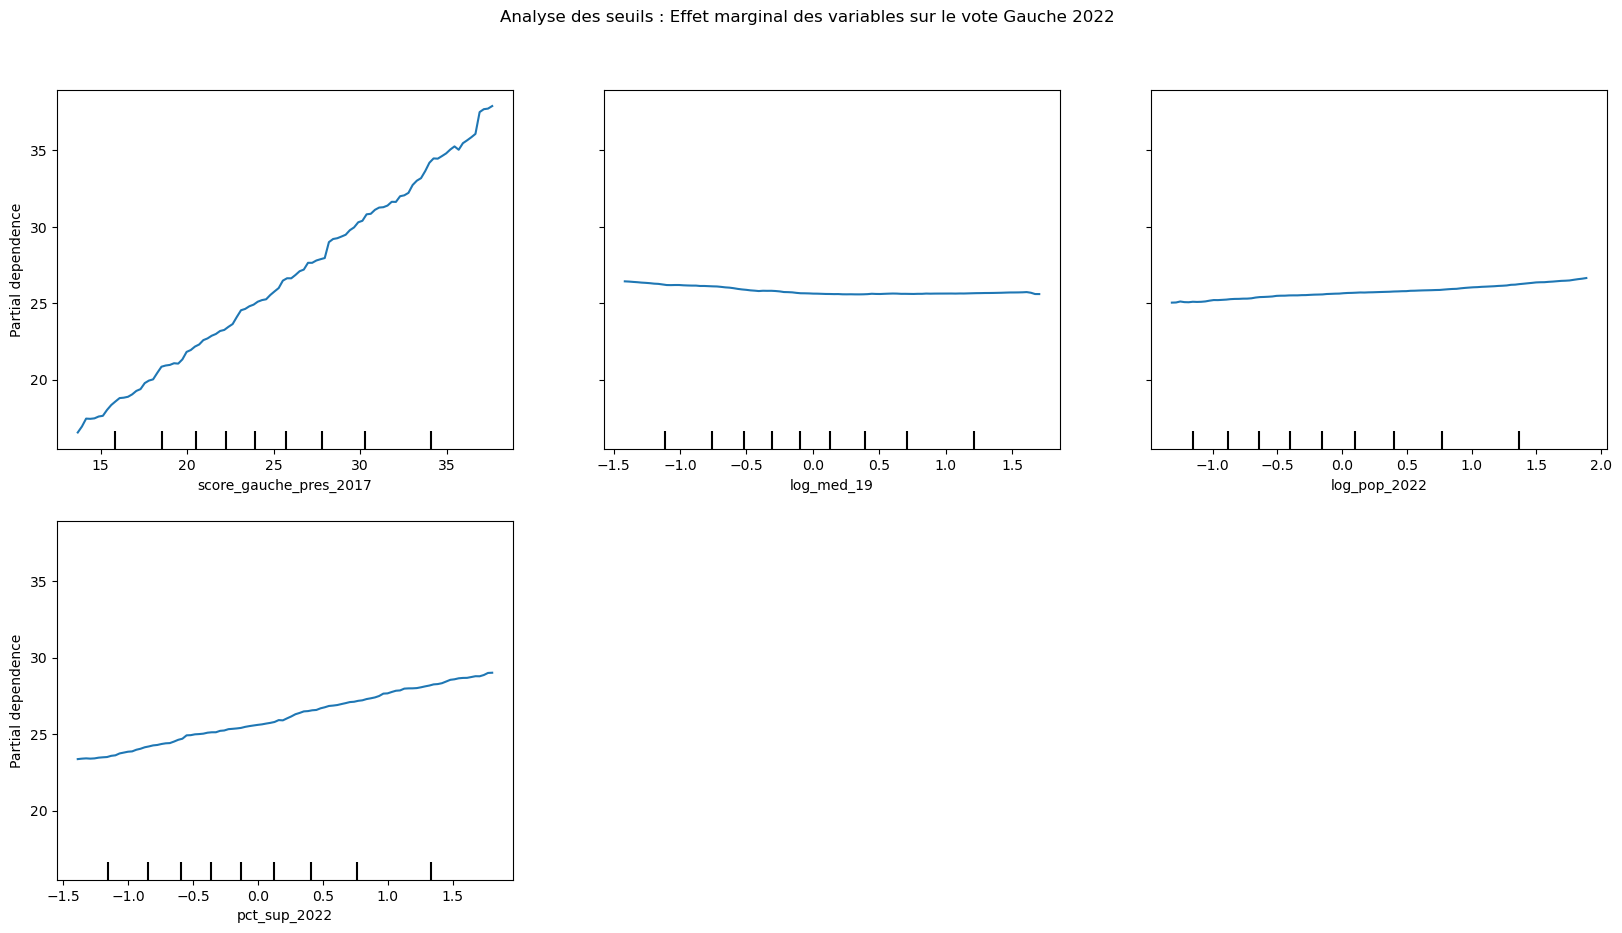

In [3]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# On choisit les variables où l'on soupçonne des seuils
features_to_plot = ['score_gauche_pres_2017', 'log_med_19', 'log_pop_2022', 'pct_sup_2022']

# Création du graphique
fig, ax = plt.subplots(figsize=(20, 10))
display = PartialDependenceDisplay.from_estimator(
    rf,          # Ton modèle Random Forest
    X,           # Tes données d'entraînement
    features_to_plot, 
    kind="average", # "average" pour la tendance globale
    ax=ax
)

plt.suptitle("Analyse des seuils : Effet marginal des variables sur le vote Gauche 2022")
plt.subplots_adjust(top=0.9)
plt.show()

cartographie des résidus: par exemple, si le modèle se trompe tout le temps en Bretagne, c'es que le modèle ne capte pas une variable culturelle/historique.

In [4]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import box
import matplotlib.pyplot as plt
import numpy as np


url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes.geojson"
communes = gpd.read_file(url)

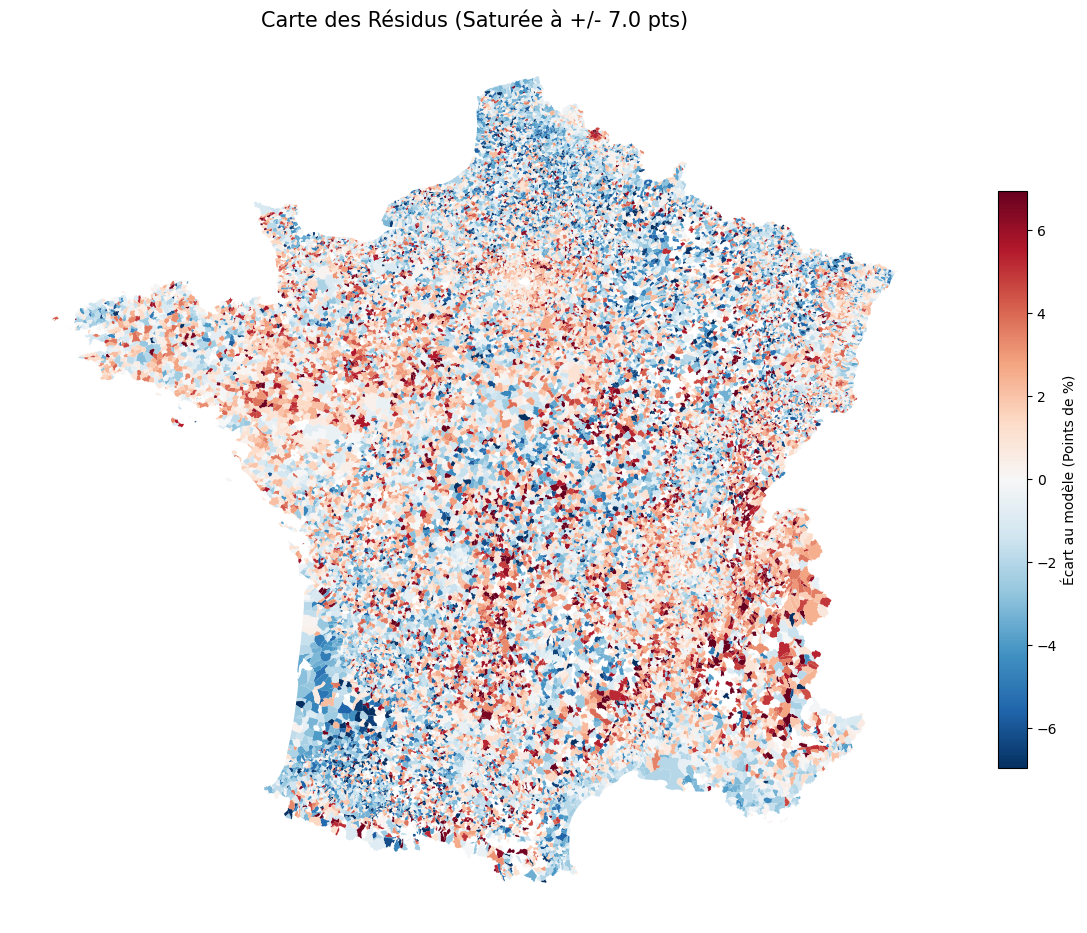

In [5]:

# 1. Calcul des résidus (Y_réel - Y_prédit)
# L'objectif est de minimiser cette fonction coût L(theta) [cite: 40, 42]
df_reg_pres['residus'] = df_reg_pres['score_gauche_pres_2022'] - rf.predict(df_reg_pres[features])

# 2. Préparation des clés (formatage 5 caractères pour la jointure)
df_reg_pres['COM'] = df_reg_pres['COM'].astype(str).str.zfill(5)
communes['code'] = communes['code'].astype(str).str.zfill(5)

# 3. Fusion des données
map_res = communes.merge(df_reg_pres, left_on='code', right_on='COM')


# 1. ZOOM : On ne garde que la France Métropolitaine (on vire les codes 97X)
# Cela "zoome" automatiquement sur l'hexagone en retirant les îles lointaines
map_focus = map_res[~map_res['code'].str.startswith('97')].copy()

# 2. CONTRASTE : On sature l'échelle (Robust Scaling)
# Au lieu du min/max absolu (qui est sensible à une erreur énorme isolée),
# on prend le 95ème centile. Tout ce qui est au-delà sera Rouge Vif ou Bleu Vif.
v_max = map_focus['residus'].abs().quantile(0.95)

# 3. VISUALISATION HD
fig, ax = plt.subplots(figsize=(15, 15)) # Taille plus grande

map_focus.plot(
    column='residus', 
    cmap='RdBu_r', 
    linewidth=0,      # SUPPRIME les bordures des communes (CRUCIAL pour la lisibilité)
    ax=ax, 
    legend=True,
    vmin=-v_max,      # On sature à -x
    vmax=v_max,       # On sature à +x
    legend_kwds={'label': "Écart au modèle (Points de %)", 'shrink': 0.5}
)

ax.set_title(f"Carte des Résidus (Saturée à +/- {v_max:.1f} pts)", fontsize=15)
ax.axis('off')
plt.show()


Tendance BLEUE (au vue de leur socio-démographie, ces gens là devraient voter à gauche mais ne le font pas = le modèle sur-estime la gauche) : côtes de nouvelle-acquitaine, hauts de france et grand Est. Votes volés par le RN, variable omise 'Age' ? 

Tendance ROUGE (ici, on vote à gauche + que ce que le modèle prédit. Le modèle sous-estime la gauche)

TO DO : faire analyse et commentaires.

Reduction de dimension (ACP) pour les variables : pas nécessaire ici avec notre modèle parcimonieux efficace

Mais une carte est pertinente pour visualiser: 


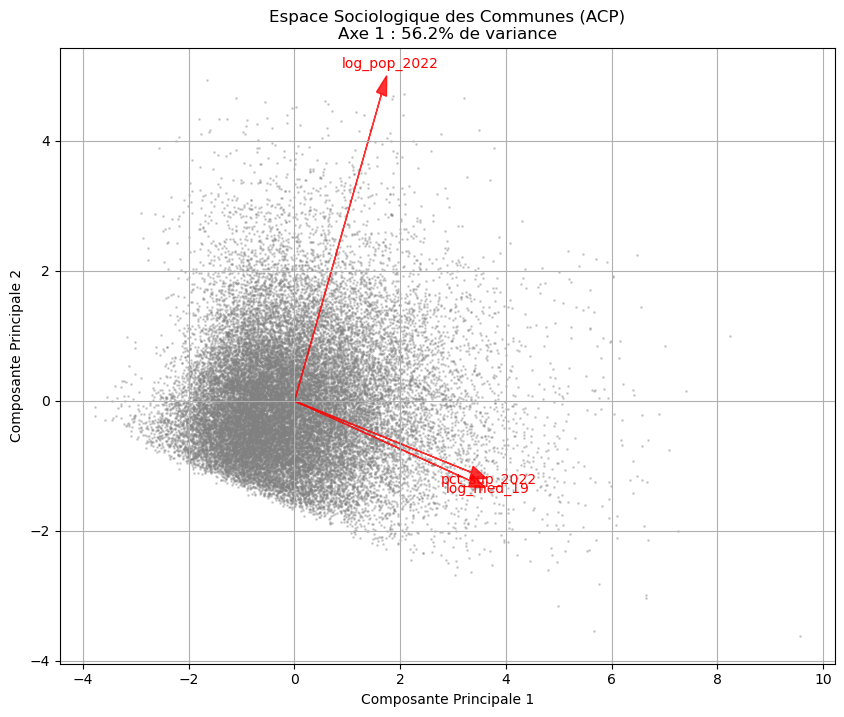

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. On reprend tes variables explicatives (SANS le vote 2017 ni 2022)
# On veut juste voir la structure SOCIO-DEMO
features_socio = ['log_pop_2022', 'log_med_19', 'pct_sup_2022']
X_socio = df_reg_pres[features_socio].dropna()

# 2. Standardisation (OBLIGATOIRE pour l'ACP)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_socio)

# 3. Calcul de l'ACP (2 composantes pour la 2D)
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

# 4. Visualisation
plt.figure(figsize=(10, 8))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.3, s=1, c='grey')

# Ajouter les vecteurs des variables (Le cercle des corrélations simplifié)
coeff = pca.components_.T
for i, feature in enumerate(features_socio):
    plt.arrow(0, 0, coeff[i, 0]*5, coeff[i, 1]*5, color='red', alpha=0.8, head_width=0.2)
    plt.text(coeff[i, 0]*5.5, coeff[i, 1]*5.5, feature, color='red', ha='center', va='center')

plt.title(f"Espace Sociologique des Communes (ACP)\nAxe 1 : {pca.explained_variance_ratio_[0]:.1%} de variance")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.grid()
plt.show()

le vote socio en france est très polarisé! 